In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Импорт датасета

df = pd.read_excel('../data/Когортный анализ.xlsx')
df

,user_id,date,price
0,A0005,2020-03-25,50
1,A0005,2020-03-25,40
2,A0005,2020-03-26,70
3,A0005,2020-03-27,20
4,A0005,2020-03-29,50
...,...,...,...
704835,Z9247,2021-01-10,20
704836,Z9247,2021-01-11,50
704837,Z9247,2021-01-11,70
704838,Z9247,2021-01-11,20


In [4]:
# Проверка на пропуски

df.isnull().any()

user_id    False
date       False
price      False
dtype: bool

Пропусков в датасете нет

In [11]:
# Создадим признок даты месяца и года первого заказа для каждого клиента(id)

df['cohort_month'] = df.groupby('user_id')['date'].transform('min') \
    .dt.to_period('M') \
    .dt.to_timestamp()

In [12]:
# Создадим признок даты месяца и года заказа для каждой строки

df['order_month'] = df.date.dt.to_period('M').dt.to_timestamp()

In [13]:
# Посчитаем и создадим признак индекса когорт

df['cohort_index'] = (df.order_month.dt.year - df.cohort_month.dt.year) * 12 + \
                     (df.order_month.dt.month - df.cohort_month.dt.month)

df

,user_id,date,price,cohort_month,month_lastorder,order_month,cohort_index
0,A0005,2020-03-25,50,2020-03-01,2020-03-01,2020-03-01,0
1,A0005,2020-03-25,40,2020-03-01,2020-03-01,2020-03-01,0
2,A0005,2020-03-26,70,2020-03-01,2020-03-01,2020-03-01,0
3,A0005,2020-03-27,20,2020-03-01,2020-03-01,2020-03-01,0
4,A0005,2020-03-29,50,2020-03-01,2020-03-01,2020-03-01,0
...,...,...,...,...,...,...,...
704835,Z9247,2021-01-10,20,2021-01-01,2021-01-01,2021-01-01,0
704836,Z9247,2021-01-11,50,2021-01-01,2021-01-01,2021-01-01,0
704837,Z9247,2021-01-11,70,2021-01-01,2021-01-01,2021-01-01,0
704838,Z9247,2021-01-11,20,2021-01-01,2021-01-01,2021-01-01,0


In [42]:
df.cohort_index.value_counts()

cohort_index
0     188679
1     129334
2      85411
3      74270
4      61839
5      45127
6      35205
7      26795
8      21102
9      15311
10     10780
11      6285
12      3941
13       761
Name: count, dtype: int64

In [48]:
# Считаем уникальных пользователей
retention_users = df.pivot_table(index='cohort_month',
                                 columns='cohort_index',
                                 values='user_id', # Столбец с ID пользователя
                                 aggfunc='nunique')
retention_users

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,,
2020-01-01,1210.0,455.0,264.0,247.0,242.0,207.0,185.0,172.0,165.0,171.0,164.0,159.0,162.0,149.0
2020-02-01,1111.0,440.0,222.0,202.0,201.0,171.0,133.0,123.0,113.0,90.0,94.0,76.0,62.0,NaN
2020-03-01,1545.0,527.0,306.0,290.0,286.0,250.0,223.0,208.0,186.0,187.0,182.0,175.0,NaN,NaN
2020-04-01,1333.0,515.0,238.0,219.0,228.0,186.0,144.0,143.0,136.0,125.0,111.0,NaN,NaN,NaN
2020-05-01,1738.0,581.0,313.0,301.0,302.0,260.0,240.0,235.0,219.0,206.0,NaN,NaN,NaN,NaN
2020-06-01,1480.0,558.0,265.0,247.0,249.0,216.0,186.0,174.0,153.0,NaN,NaN,NaN,NaN,NaN
2020-07-01,1995.0,649.0,332.0,312.0,293.0,256.0,243.0,224.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,1744.0,643.0,285.0,265.0,263.0,227.0,196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,2081.0,701.0,336.0,312.0,303.0,266.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


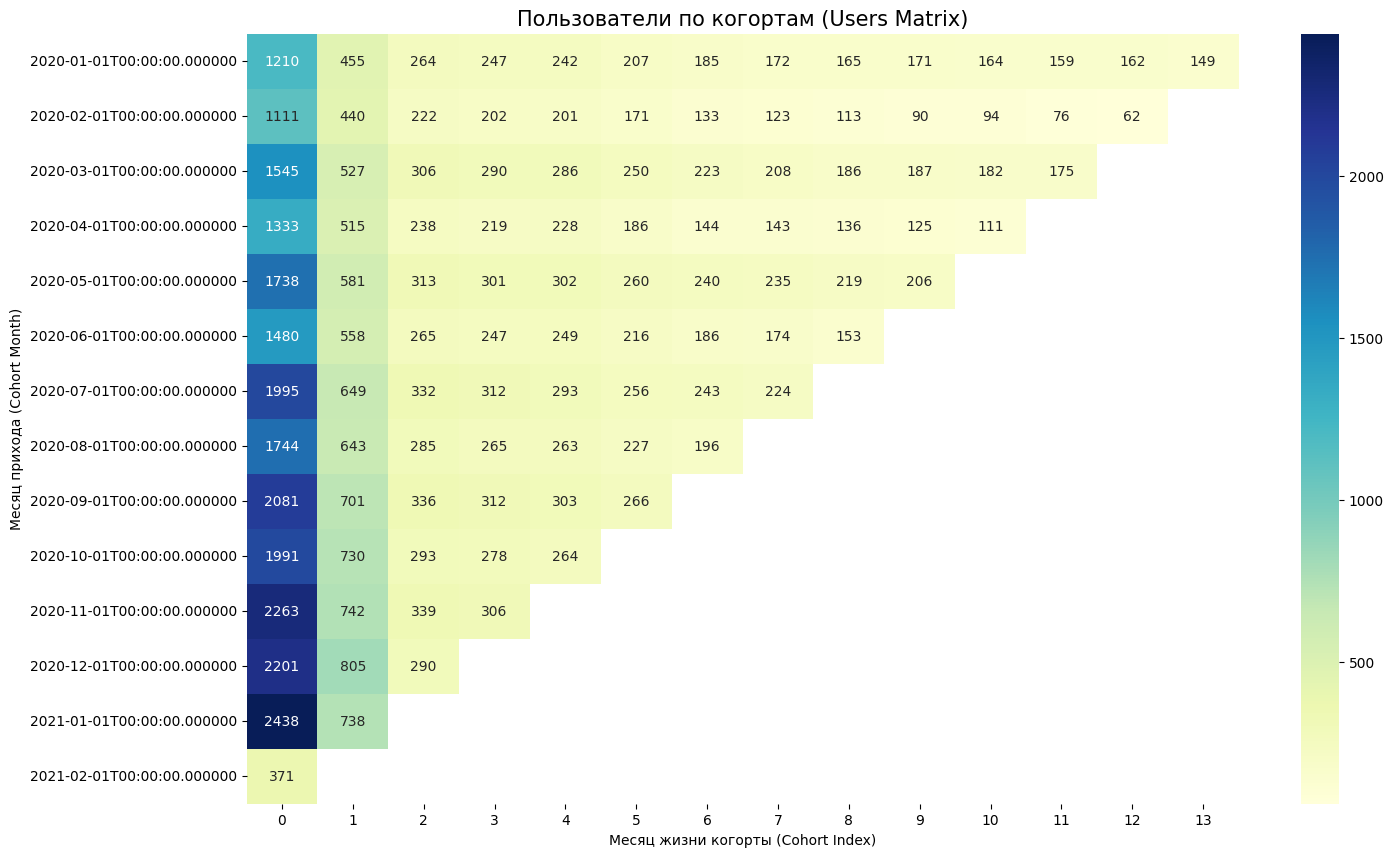

In [49]:
plt.figure(figsize=(16, 10))
plt.title('Пользователи по когортам (Users Matrix)', fontsize=15)

# Строим heatmap
# annot=True добавит числа в ячейки
# fmt='.0f' уберет десятичные знаки после запятой
# cmap='YlGnBu' сделает красивый переход от желтого к синему
sns.heatmap(retention_users, annot=True, fmt='.0f', cmap='YlGnBu')

plt.xlabel('Месяц жизни когорты (Cohort Index)')
plt.ylabel('Месяц прихода (Cohort Month)')
plt.show()


Наблюдается критический уровень Churn Rate (оттока) непосредственно после первого месяца взаимодействия (индекс 1). Потеря 60–70% клиентской базы на старте свидетельствует о проблемах на этапе активации (Onboarding). Несмотря на высокую эффективность каналов привлечения (Acquisition), бизнес сталкивается с барьером «первого касания», когда продукт или сервис не формирует у новичков привычку к потреблению

In [44]:
# Считаем сумму заказов
retention_money = df.pivot_table(index='cohort_month',
                                 columns='cohort_index',
                                 values='price', 
                                 aggfunc='sum')
retention_money

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,,
2020-01-01,662180.0,642990.0,608410.0,565650.0,547080.0,483840.0,455490.0,412040.0,407790.0,428040.0,382000.0,371740.0,360570.0,79310.0
2020-02-01,536310.0,594210.0,445590.0,450500.0,409640.0,366150.0,300350.0,278920.0,251840.0,212570.0,194800.0,156240.0,31080.0,NaN
2020-03-01,873000.0,797300.0,680220.0,666890.0,646610.0,546210.0,542030.0,486430.0,461720.0,465630.0,447040.0,90390.0,NaN,NaN
2020-04-01,648770.0,667480.0,526090.0,503450.0,482350.0,378620.0,354250.0,332740.0,329710.0,314460.0,61750.0,NaN,NaN,NaN
2020-05-01,992030.0,870090.0,737430.0,740850.0,699940.0,633220.0,584100.0,572410.0,568870.0,115380.0,NaN,NaN,NaN,NaN
2020-06-01,718980.0,759810.0,563430.0,559150.0,545300.0,472750.0,453890.0,411240.0,78310.0,NaN,NaN,NaN,NaN,NaN
2020-07-01,1106840.0,913300.0,739440.0,735260.0,661290.0,634590.0,604380.0,124890.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,844520.0,800350.0,607090.0,586730.0,603010.0,517030.0,94600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,1164460.0,979070.0,784700.0,778600.0,710410.0,140880.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


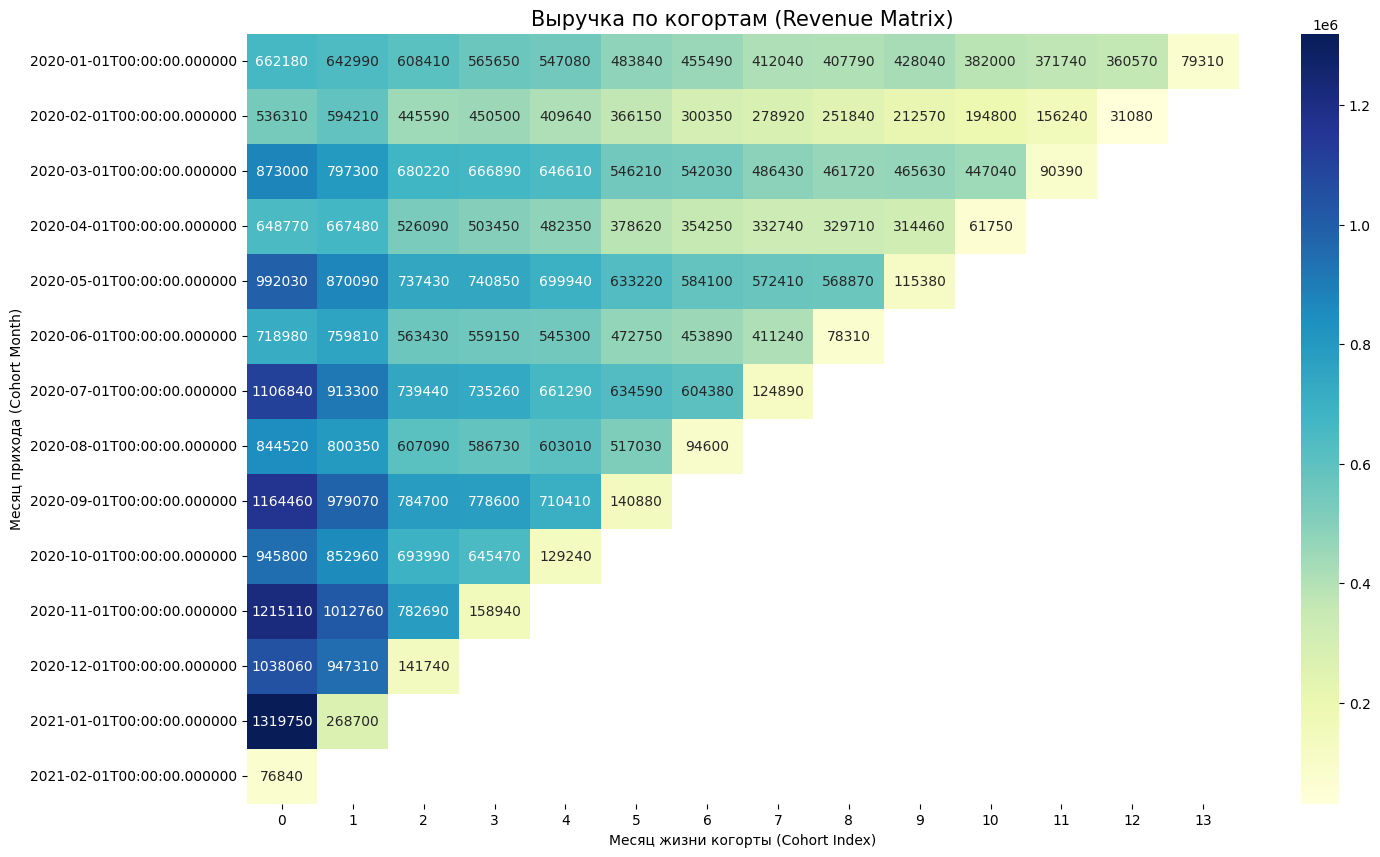

In [47]:
plt.figure(figsize=(16, 10))
plt.title('Выручка по когортам (Revenue Matrix)', fontsize=15)

# Строим heatmap
# annot=True добавит числа в ячейки
# fmt='.0f' уберет десятичные знаки после запятой
# cmap='YlGnBu' сделает красивый переход от желтого к синему
sns.heatmap(retention_money, annot=True, fmt='.0f', cmap='YlGnBu')

plt.xlabel('Месяц жизни когорты (Cohort Index)')
plt.ylabel('Месяц прихода (Cohort Month)')
plt.show()


Несмотря на кратное сокращение численности активных клиентов ко второму месяцу, падение выручки непропорционально мало (10–20%), что указывает на феномен «Золотого ядра». Оставшиеся пользователи демонстрируют резкий рост среднего чека (AOV) и частоты транзакций. Это подтверждает высокую ценность лояльного сегмента: удержание одного «старого» клиента экономически эффективнее привлечения 3–5 новых

Итог: Анализ когортной динамики за 2020–2021 гг. выявил высокую поляризацию базы, где 60–70% первичного оттока контрастирует с высокой LTV «Золотого ядра», обеспечивающего стабильность выручки при значительном снижении количества активных пользователей. В то время как масштабирование (когорта 2021-01) увеличило приток, оно снизило качество удержания, смещая фокус на критическую необходимость оптимизации активации (Onboarding) и снижения оттока в первом месяце.Ключевая задача для обеспечения экспоненциального роста — снижение первичного Churn Rate на 10%, что позволит трансформировать «холодную» аудиторию в лояльных клиентов, стабилизируя их активность после 3-4 месяцев жизненного цикла.

Рекомендация: Стратегический приоритет должен быть смещен с агрессивного привлечения на Retention-маркетинг первого месяца. Снижение оттока на этапе «первого касания» даже на 10% способно обеспечить экспоненциальный рост накопленной прибыли за счет высокой монетизации «ядра» в последующие периоды.